In [ ]:
                                            Adam Optimizer (Adaptive Moment Estimation)

In [ ]:
what is ADAM :-
                Adam Optimizer (Adaptive Moment Estimation) deep learning mein sabse zyada popular optimizers mein se ek hai.
                Yeh optimizer momentum aur RMSprop ke concepts ko mila kar kaam karta hai, jisme yeh learning rate ko adaptively update 
                karta hai aur gradient ke moments ko accumulate karta hai. Adam ki khasiyat yeh hai ki yeh fast convergence aur accurate 
                optimization ke liye effective hota hai, especially for large datasets aur noisy data.

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import  Adam, RMSprop, SGD, Adagrad
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\covid_toy.csv")
df["fever"].fillna(df["fever"].mean(),inplace=True)
cat = df.select_dtypes(include=["object"]).columns
for i in cat:
    l = LabelEncoder()
    df[i]=l.fit_transform(df[i])
df.head()
X = df.drop("has_covid",axis=1)
y = df["has_covid"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6948\2701639432.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fever"].fillna(df["fever"].mean(),inplace=True)


In [17]:
s = StandardScaler()
X_train =s.fit_transform(X_train)
X_test = s.transform(X_test)

In [21]:
def create_model():
    model = Sequential()
    model.add(Dense(32,input_dim=X_train.shape[1],activation="relu"))
    model.add(Dense(16,activation="relu"))
    model.add(Dense(1,activation="sigmoid"))
    return model
create_model()

<Sequential name=sequential, built=True>

In [27]:
model_momentam = create_model()
model_optimizers = SGD(learning_rate=0.01,momentum=0.7)
model_momentam.compile(optimizer=model_optimizers, loss='binary_crossentropy', metrics=['accuracy'])
history_momentam= model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

In [33]:
model_momentam = create_model()
model_optimizers = SGD(learning_rate=0.01,momentum=0.7,nesterov=True)
model_momentam.compile(optimizer=model_optimizers, loss='binary_crossentropy', metrics=['accuracy'])
history_nag= model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

In [38]:
model_momentam = create_model()
model_optimizers = Adagrad(learning_rate=0.01)
model_momentam.compile(optimizer=model_optimizers, loss='binary_crossentropy', metrics=['accuracy'])
history_adagrad= model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

In [35]:
model_momentam = create_model()
model_optimizers = RMSprop(learning_rate=0.01)
model_momentam.compile(optimizer=model_optimizers, loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop= model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

In [36]:
model_momentam = create_model()
model_optimizers = Adam(learning_rate=0.01)
model_momentam.compile(optimizer=model_optimizers, loss='binary_crossentropy', metrics=['accuracy'])
history_adam= model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

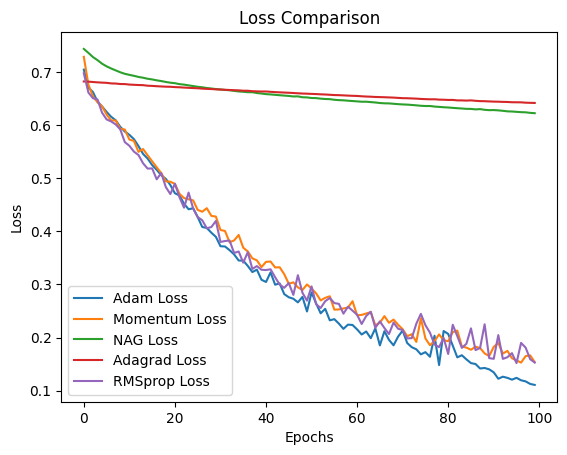

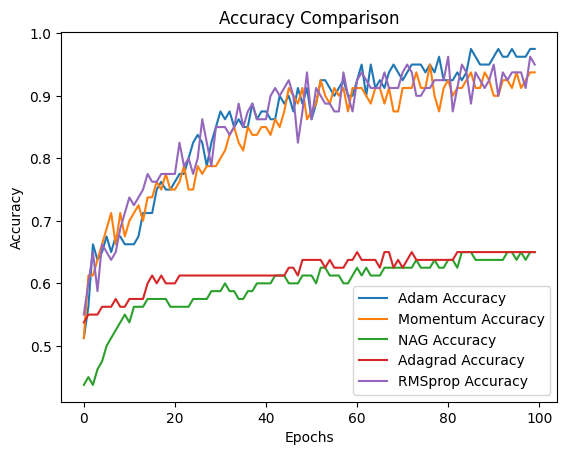

In [39]:
import matplotlib.pyplot as plt

# Loss comparison
plt.plot(history_adam.history['loss'], label='Adam Loss')
plt.plot(history_momentam.history['loss'], label='Momentum Loss')
plt.plot(history_nag.history['loss'], label='NAG Loss')
plt.plot(history_adagrad.history['loss'], label='Adagrad Loss')
plt.plot(history_rmsprop.history['loss'], label='RMSprop Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy comparison
plt.plot(history_adam.history['accuracy'], label='Adam Accuracy')
plt.plot(history_momentam.history['accuracy'], label='Momentum Accuracy')
plt.plot(history_nag.history['accuracy'], label='NAG Accuracy')
plt.plot(history_adagrad.history['accuracy'], label='Adagrad Accuracy')
plt.plot(history_rmsprop.history['accuracy'], label='RMSprop Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
